Տնային առաջադրանքը կատարելու վերջնաժամկետը **21.06.2021 15:30** է։ Առաջադրանքները կատարելուց հետո, պետք է 

1. ներբեռնեք այս ֆայլը ձեր համակարգիչ (`File` $\to$ `Download .ipynb`)

2. ներբեռնեք լրացված ``.py`` ֆայլերը

3. վերոնշյալ ֆայլերը ``.zip`` արեք և վերնագրեք հետևյալ ֆորմատով՝ 
*HW5_AnunAzganun.zip* 

4. ուղարկեք ֆայլը **fast.1991.ml@gmail.com n** հասցեին` նամակի թեմա (subject) դաշտում գրելով **ML5**

**Ուշադրություն**․ 
Վերոնշյալ պայմաններին չբավարարելու դեպքում ձեր աշխատանքը չի գնահատվի։

# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid') # Plot style

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

%load_ext autoreload
%autoreload 2

Import the dataset `data.csv` from the `Lab_files/Lab5` folder and complete the `MyLinearRegression` class in `regression.py` script.

In [2]:
data = pd.read_csv("data.csv", index_col = 0)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['y']),
                                                    data['y'], test_size=0.5,
                                                    random_state=0 )

In [4]:
from linear_regression import MyLinearRegression

In [5]:
model = MyLinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)
our_mse = mean_squared_error(preds, y_test)

The below cell should run without errors if you have implemented the linear regression without regularization correctly.

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
sklearn_mse = mean_squared_error(pred, y_test)
assert np.round(our_mse, 2) == np.round(sklearn_mse, 2)

In [7]:
model = MyLinearRegression(regularization='l2', lam=1)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print('Our mse:', mean_squared_error(preds, y_test))

Our mse: 19.60867107404954


In [8]:
model = Ridge()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Sklearn mse:', mean_squared_error(pred, y_test))

Sklearn mse: 19.768875531967034


In [9]:
# I tried to change hiper-parametrs to get low mse
model = MyLinearRegression(regularization='l1',
                         lam=1, 
                         learning_rate=0.001,
                         tol=0.0003)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print('Our mse:', mean_squared_error(preds, y_test))

Converged in 11711 steps
Our mse: 20.34153045055697


In [56]:
model = MyLinearRegression(regularization='l1', tol=0.005)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print('Our mse:', mean_squared_error(preds, y_test))

Converged in 1089 steps
Our mse: 84.88258202126019


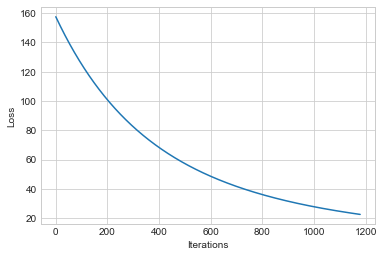

In [54]:
plt.plot(model.loss)
plt.xlabel('Iterations')
plt.ylabel('Loss');

In [11]:
model = Lasso()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Sklearn mse:', mean_squared_error(pred, y_test))

Sklearn mse: 29.163706191617788
